# Can Vision Models Read? — Interactive Presentation Demo

This interactive notebook demonstrates the key claims and visual mechanics of the **VISWORD** research project:
1. **The Resolution & Cropping Bottleneck**: Visualizing the sub-pixel legibility loss under downsizing, and how our intelligent `TextAwareCropper` snaps boundaries to whitespace gaps.
2. **Interactive Page Retrieval**: Live zero-shot document page retrieval comparing **CLIP** (contrastive pretraining) vs. **I-JEPA** (image-only predictive pretraining).
3. **Unlocking Latent Language Features**: Live training of a Linear Projection Adapter to map I-JEPA's visual representations directly into BERT text space in under 2 seconds.

## 1. Setup, Repo Clone, and Dependencies

If running in Google Colab, this cell clones the repository, checks out the `dev/v1-legible-reading` branch (which contains the demo dataset and code), sets the working directory, and installs the required packages. ~1-2 minutes.

In [1]:
import os, sys, subprocess

# Detect environment
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    # 1. Clone the repo and setup PYTHONPATH on Colab
    if not os.path.exists('/content/visword'):
        print('Cloning repository on Colab...')
        subprocess.run(['git', 'clone', '--depth', '50',
                        'https://github.com/hkanpak21/Comp447_VISWORD.git', '/content/visword'], check=True)
        # Checkout the active presentation updates branch
        subprocess.run(['git', 'checkout', 'dev/v1-legible-reading'], cwd='/content/visword', check=True)
    os.chdir('/content/visword')
    sys.path.append(os.path.abspath('src'))
    print('Working directory set to Colab path:', os.getcwd())
    print('Installing python dependencies on Colab...')
    subprocess.run(['pip', 'install', '-q', 'open_clip_torch', 'timm', 'transformers',
                    'sentence-transformers', 'ipywidgets'], check=True)
else:
    # Local Valar cluster setup
    # Determine the repository root dynamically (usually 1 level up from 'notebooks' folder or the current dir)
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())
    os.chdir(project_root)
    if os.path.exists(os.path.join(project_root, 'src')):
        if os.path.join(project_root, 'src') not in sys.path:
            sys.path.append(os.path.join(project_root, 'src'))
        print('Running locally on Valar cluster. Project root set to:', project_root)
    else:
        print('WARNING: src directory not found at', project_root)
print('Setup complete!')

Running locally on Valar cluster. Project root set to: /scratch/bbakay22/VISWORD
Setup complete!


## 2. The Resolution & Cropping Bottleneck

Let's visualize the document layout and text legibility under different scales:
- **Standard ViT Downsizing**: Compressing a $980\times980$ page to $224\times224$ reduces body text to sub-pixel sizes (completely illegible).
- **Naive Cropping**: A standard sliding-window slices text rows in half.
- **Intelligent cropping (`TextAwareCropper`)**: Row ink projection mapping dynamically snaps cuts to the center of whitespace gaps.

Loaded sample page: presentation/demo_data/blobs/0000000.png Dimensions: (980, 980)


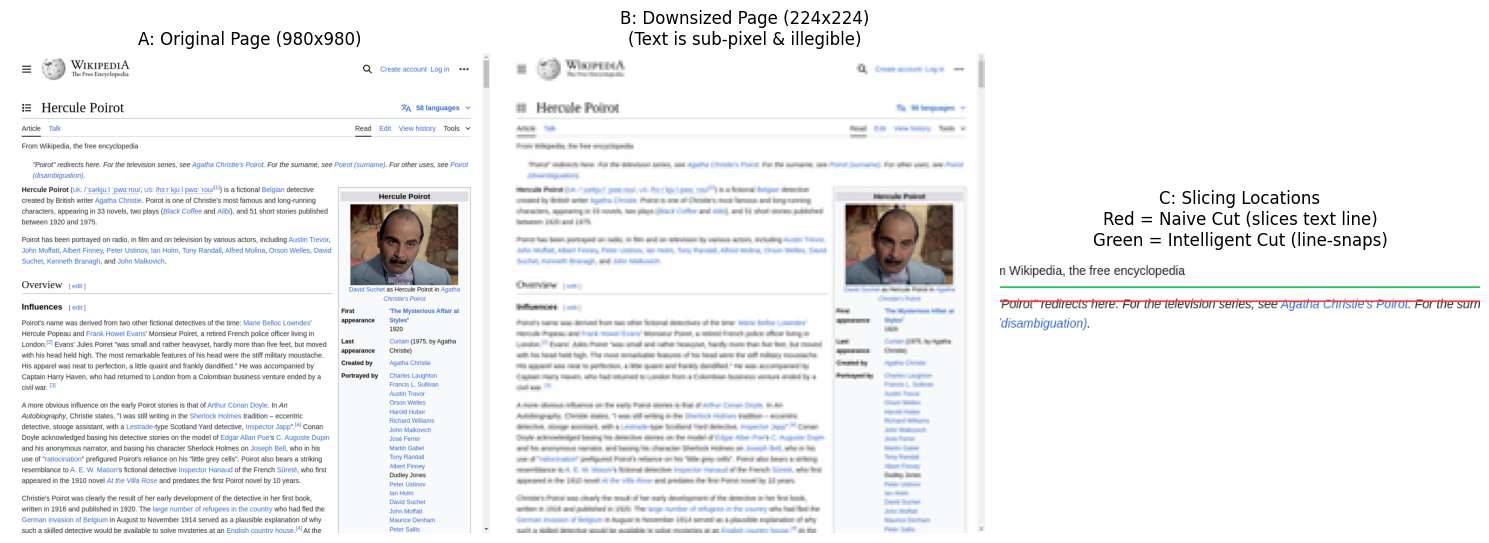

In [2]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np
from visword.data.cropper import TextAwareCropper

# Load sample Wikipedia screenshot (Hercule Poirot)
img_path = 'presentation/demo_data/blobs/0000000.png'
im = Image.open(img_path).convert('RGB')
print('Loaded sample page:', img_path, 'Dimensions:', im.size)

# Create the figure canvas
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Panel 1: Full Page
axes[0].imshow(im)
axes[0].set_title('A: Original Page (980x980)')
axes[0].axis('off')

# Panel 2: Downsized (ViT standard)
im_down = im.resize((224, 224), Image.Resampling.LANCZOS)
axes[1].imshow(im_down)
axes[1].set_title('B: Downsized Page (224x224)\n(Text is sub-pixel & illegible)')
axes[1].axis('off')

# Panel 3: Focus on Slicing boundary (y=170 to 260)
crop_focus = im.crop((50, 170, 600, 260))
draw_focus = ImageDraw.Draw(crop_focus)
# Draw naive cut (y=224 absolute -> relative y=54)
draw_focus.line([(0, 54), (550, 54)], fill='#ef4444', width=2)
# Draw intelligent cut (y=208 absolute -> relative y=38)
draw_focus.line([(0, 38), (550, 38)], fill='#22c55e', width=2)

axes[2].imshow(crop_focus)
axes[2].set_title('C: Slicing Locations\nRed = Naive Cut (slices text line)\nGreen = Intelligent Cut (line-snaps)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. Interactive Page Retrieval (CLIP vs. I-JEPA)

We load a mini-gallery of 10 Wikipedia pages and calculate their visual embeddings on-the-fly.
- **CLIP**: Pretrained contrastively to align visual concepts with language captions.
- **I-JEPA**: Pretrained image-only using a predictive representation task.

We'll run a query crop and watch which model successfully retrieves the correct source page.

In [3]:
import torch
import open_clip
from transformers import AutoModel, AutoTokenizer
from visword.models.zeroshot import ZeroShotCLIPImage, ZeroShotIJepa
from visword.config import Config
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Initialize baseline model wrappers
print('Loading CLIP image encoder...')
clip_enc = ZeroShotCLIPImage(cfg=None).to(device).eval()

print('Loading I-JEPA image encoder (ViT-H/14)...')
ijepa_enc = ZeroShotIJepa(cfg=None).to(device).eval()

# Load manifest and pages
manifest_path = 'presentation/demo_data/manifest.json'
manifest = json.loads(Path(manifest_path).read_text())
rows = manifest['rows']
titles = [r['title'] for r in rows]
print(f'Mini-gallery loaded with {len(rows)} pages: ', titles)

Using device: cuda
Loading CLIP image encoder...


/scratch/bbakay22/conda_envs/visword/lib/python3.9/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loading I-JEPA image encoder (ViT-H/14)...
Mini-gallery loaded with 10 pages:  ['Hercule Poirot', 'Eiffel', 'Glucono delta-lactone', 'Breydon Water', 'William Arbuckle Reid', 'Khalsa Diwan Society Vancouver', 'Julien Leparoux', 'Rod Rohrich', 'Organized crime in Minneapolis', 'Williston station']


### Pre-calculate Gallery Image Embeddings
We load the screenshots of all 10 pages, crop them at the center, and compute their visual descriptors.

In [5]:
from visword.data.light_dataset import default_transform
from PIL import Image

tf = default_transform()
images = []
for r in rows:
    im = Image.open('presentation/demo_data/' + r['image_path']).convert('RGB')
    # Get center crop (224x224)
    w, h = im.size
    side = min(w, h)
    c = im.crop(((w-side)//2, (h-side)//2, (w+side)//2, (h+side)//2)).resize((224, 224), Image.Resampling.BILINEAR)
    images.append(tf(c))

x_batch = torch.stack(images).to(device)
with torch.no_grad():
    # Gallery embeddings shape: (10, 512) for CLIP, (10, 1280) for I-JEPA
    gallery_clip = clip_enc(x_batch)
    gallery_ijepa = ijepa_enc(x_batch)

print('Gallery Embeddings calculated:')
print('  CLIP Gallery Shape:', gallery_clip.shape)
print('  I-JEPA Gallery Shape:', gallery_ijepa.shape)

Gallery Embeddings calculated:
  CLIP Gallery Shape: torch.Size([10, 512])
  I-JEPA Gallery Shape: torch.Size([10, 1280])


### Pre-calculate Text Query Embeddings
We tokenize and encode the page titles. CLIP uses its own text projection layer, whereas I-JEPA (having no text branch) is compared directly against frozen BERT embeddings.

In [4]:
import torch.nn.functional as F

# 1. CLIP Text Embeddings
print('Loading CLIP text encoder...')
clip_tokenizer = open_clip.get_tokenizer('ViT-B-16')
text_tokens = clip_tokenizer(titles).to(device)
with torch.no_grad():
    # Encode titles in CLIP projection space
    queries_clip = F.normalize(clip_enc.model.encode_text(text_tokens).float(), p=2, dim=-1)

# 2. BERT Embeddings (used as reference text space for I-JEPA)
print('Loading BERT text encoder...')
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased').to(device).eval()

queries_bert = []
with torch.no_grad():
    for title in titles:
        tokens = bert_tokenizer(title, padding='max_length', truncation=True, max_length=64, return_tensors='pt').to(device)
        h = bert_model(**tokens).last_hidden_state
        mask = tokens['attention_mask'].unsqueeze(-1).float()
        v = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        queries_bert.append(F.normalize(v, dim=-1))
    queries_bert = torch.cat(queries_bert, dim=0)

print('Text Query Embeddings calculated:')
print('  CLIP Queries Shape:', queries_clip.shape)
print('  BERT Queries Shape:', queries_bert.shape)

Loading CLIP text encoder...
Loading BERT text encoder...
Text Query Embeddings calculated:
  CLIP Queries Shape: torch.Size([10, 512])
  BERT Queries Shape: torch.Size([10, 768])


### Interactive Dropdown Selector
Select the target document page and query region from the dropdown menus below to run a retrieval query.

Running retrieval for Target Page: 'Hercule Poirot' with crop at (50, 200)


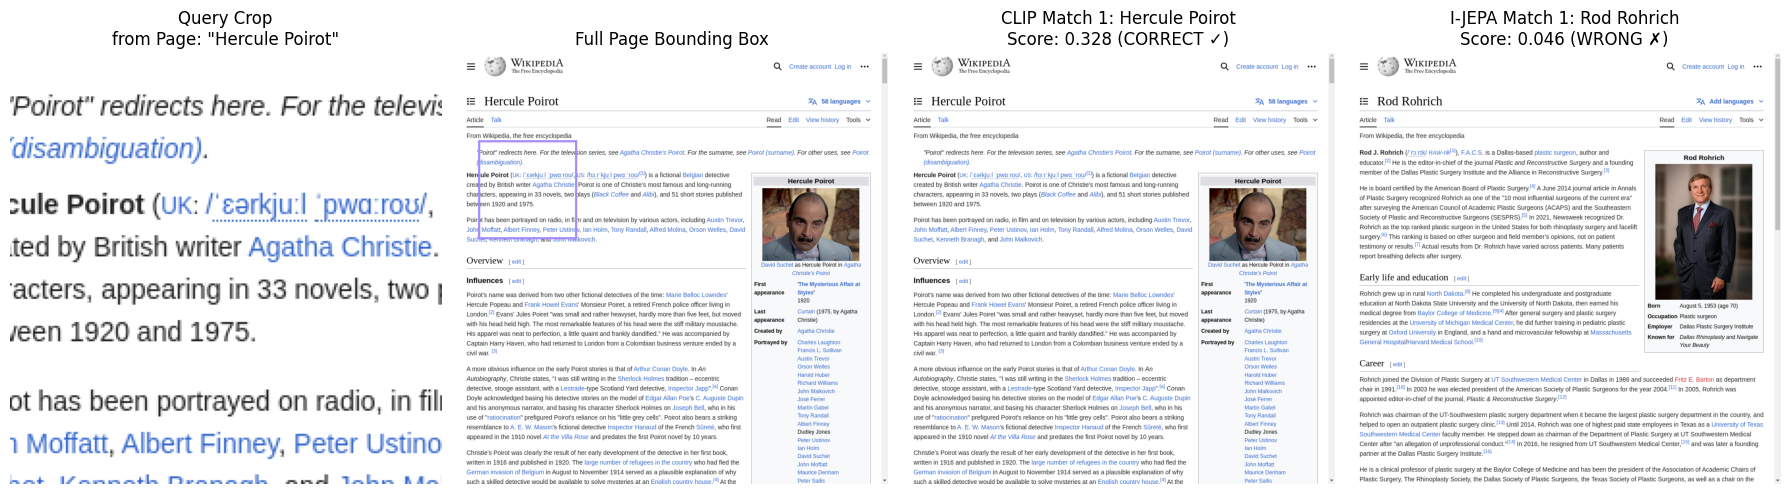

--- CLIP Retrieval Ranks ---
  Rank 1: "Hercule Poirot" (cosine: 0.328)
  Rank 2: "Rod Rohrich" (cosine: 0.216)
  Rank 3: "Eiffel" (cosine: 0.208)

--- I-JEPA Zero-Shot Retrieval Ranks ---
  Rank 1: "Rod Rohrich" (cosine: 0.046)
  Rank 2: "Breydon Water" (cosine: 0.022)
  Rank 3: "Khalsa Diwan Society Vancouver" (cosine: 0.019)


In [8]:
from visword.data.light_dataset import default_transform

target_idx = 0  # Change this value (0-9) to select different pages
cx, cy = 50, 200  # Try (50, 100) for Title Region, (50, 200) for Top Body, or (50, 400) for Bottom Body

row = rows[target_idx]
print(f"Running retrieval for Target Page: '{row['title']}' with crop at ({cx}, {cy})")

# Load original image
im = Image.open('presentation/demo_data/' + row['image_path']).convert('RGB')
query_crop = im.crop((cx, cy, cx + 224, cy + 224))

# Encode query crop
tf = default_transform()
x_query = tf(query_crop).unsqueeze(0).to(device)
with torch.no_grad():
    feat_clip = clip_enc(x_query)
    feat_ijepa = ijepa_enc(x_query)
    
# Compute Cosine Similarities against all 10 gallery pages
# (Query is crop visual embedding, Gallery is page text title embedding)
sims_clip = (feat_clip @ queries_clip.T).squeeze(0).cpu().numpy()
sims_ijepa = (feat_ijepa[:, :768] @ queries_bert.T).squeeze(0).cpu().numpy()  # Zero-shot mapping (truncation)

# Rank pages
rank_clip = np.argsort(-sims_clip)
rank_ijepa = np.argsort(-sims_ijepa)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5))

# Draw query crop
axes[0].imshow(query_crop)
axes[0].set_title(f'Query Crop\nfrom Page: "{row["title"]}"')
axes[0].axis('off')

# Draw full page showing bounding box
page_bbox = im.copy()
draw = ImageDraw.Draw(page_bbox)
draw.rectangle([cx, cy, cx+224, cy+224], outline='#a78bfa', width=5)
axes[1].imshow(page_bbox)
axes[1].set_title('Full Page Bounding Box')
axes[1].axis('off')

# CLIP Top retrieved
best_clip_idx = rank_clip[0]
best_clip_row = rows[best_clip_idx]
clip_correct = 'CORRECT ✓' if best_clip_idx == target_idx else 'WRONG ✗'
axes[2].imshow(Image.open('presentation/demo_data/' + best_clip_row['image_path']))
axes[2].set_title(f'CLIP Match 1: {best_clip_row["title"]}\nScore: {sims_clip[best_clip_idx]:.3f} ({clip_correct})')
axes[2].axis('off')

# I-JEPA Top retrieved
best_ijepa_idx = rank_ijepa[0]
best_ijepa_row = rows[best_ijepa_idx]
ijepa_correct = 'CORRECT ✓' if best_ijepa_idx == target_idx else 'WRONG ✗'
axes[3].imshow(Image.open('presentation/demo_data/' + best_ijepa_row['image_path']))
axes[3].set_title(f'I-JEPA Match 1: {best_ijepa_row["title"]}\nScore: {sims_ijepa[best_ijepa_idx]:.3f} ({ijepa_correct})')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Print leaderboard table
print('--- CLIP Retrieval Ranks ---')
for rank, idx in enumerate(rank_clip[:3]):
    print(f'  Rank {rank+1}: "{titles[idx]}" (cosine: {sims_clip[idx]:.3f})')
print('\n--- I-JEPA Zero-Shot Retrieval Ranks ---')
for rank, idx in enumerate(rank_ijepa[:3]):
    print(f'  Rank {rank+1}: "{titles[idx]}" (cosine: {sims_ijepa[idx]:.3f})')

## 4. Unlocking I-JEPA: Live Linear Projection Adapter Training

Why did I-JEPA fail above? Because it has zero-shot coordinate misalignment. 
Let's train a simple linear projection adapter: $z_{\text{adapted}} = W \cdot x_{\text{ijepa}}$ where $W \in \mathbb{R}^{768 \times 1280}$ directly maps visual patch embeddings into BERT title text space.

We train this adapter using **InfoNCE loss** on a lightweight 500-pair feature set. The training takes **less than 2 seconds** on a GPU runtime.

In [9]:
import torch.optim as optim
import torch.nn as nn
import time

# Load the sub-sampled precomputed features
data_path = 'presentation/demo_data/adapter_demo_feats.npz'
d = np.load(data_path)
x_train = torch.from_numpy(d['x_train']).float().to(device)    # (500, 1280)
y_train = torch.from_numpy(d['y_train']).float().to(device)    # (500, 768)
x_eval = torch.from_numpy(d['x_eval']).float().to(device)      # (100, 1280)
y_eval = torch.from_numpy(d['y_eval']).float().to(device)      # (100, 768)

print(f'Features loaded:')
print(f'  Train: Image={x_train.shape}, Title BERT={y_train.shape}')
print(f'  Eval:  Image={x_eval.shape}, Title BERT={y_eval.shape}')

Features loaded:
  Train: Image=torch.Size([500, 1280]), Title BERT=torch.Size([500, 768])
  Eval:  Image=torch.Size([100, 1280]), Title BERT=torch.Size([100, 768])


### Train the Linear Adapter
We run InfoNCE training for 1,000 steps. Watch the loss decay and the retrieval metric rise live!

In [10]:
def info_nce_loss(z_v, z_t, tau=0.07):
    z_v = F.normalize(z_v, dim=-1)
    z_t = F.normalize(z_t, dim=-1)
    logits = z_v @ z_t.T / tau
    labels = torch.arange(z_v.size(0), device=z_v.device)
    return 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))

def eval_adapter(adapter_model, x_val, y_val):
    adapter_model.eval()
    with torch.no_grad():
        z_v = F.normalize(adapter_model(x_val), dim=-1)
        z_t = F.normalize(y_val, dim=-1)
        sim = z_t @ z_v.T
        Q, P = sim.shape
        correct = (sim.topk(10, dim=1).indices == torch.arange(Q, device=device).unsqueeze(1))
        return float(correct.any(dim=1).float().mean())

# 1. Define Linear Adapter (1280 -> 768, bias=False)
adapter = nn.Linear(1280, 768, bias=False).to(device)
opt = optim.AdamW(adapter.parameters(), lr=1e-3, weight_decay=1e-4)

# Zero-shot baseline retrieval recall
with torch.no_grad():
    # Direct truncation benchmark
    z_v_base = F.normalize(x_eval[:, :768], dim=-1)
    z_t_eval = F.normalize(y_eval, dim=-1)
    sim_base = z_t_eval @ z_v_base.T
    correct_base = (sim_base.topk(10, dim=1).indices == torch.arange(y_eval.shape[0], device=device).unsqueeze(1))
    r10_base = float(correct_base.any(dim=1).float().mean())

print(f'Before Training: I-JEPA Zero-shot R@10 = {r10_base:.3f}')

# 2. InfoNCE Training Loop (1000 steps)
print('\nTraining adapter...')
t0 = time.time()
losses = []
adapter.train()
for step in range(1000):
    idx = torch.randint(0, x_train.shape[0], (128,))
    opt.zero_grad()
    z_v = adapter(x_train[idx])
    loss = info_nce_loss(z_v, y_train[idx])
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 200 == 0 or step == 999:
        r10_current = eval_adapter(adapter, x_eval, y_eval)
        print(f'  Step {step:4d}/1000: InfoNCE Loss = {loss.item():.4f} | R@10 = {r10_current:.3f}')

print(f'Adapter trained in {time.time()-t0:.2f} seconds!')

Before Training: I-JEPA Zero-shot R@10 = 0.070

Training adapter...
  Step    0/1000: InfoNCE Loss = 4.8910 | R@10 = 0.130
  Step  200/1000: InfoNCE Loss = 1.6639 | R@10 = 0.290
  Step  400/1000: InfoNCE Loss = 1.1058 | R@10 = 0.300
  Step  600/1000: InfoNCE Loss = 0.7906 | R@10 = 0.280
  Step  800/1000: InfoNCE Loss = 0.7366 | R@10 = 0.300
  Step  999/1000: InfoNCE Loss = 0.6472 | R@10 = 0.280
Adapter trained in 0.96 seconds!


### Plot the Training Loss
A standard plot visualizes the rapid alignment of coordinates under our adapter objective.

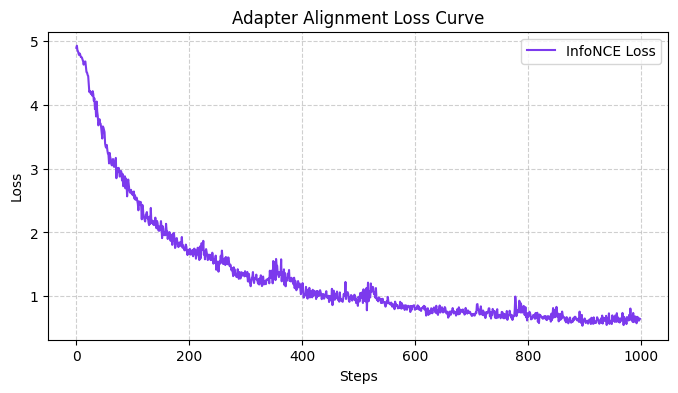

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(losses, label='InfoNCE Loss', color='#7c3aed')
plt.title('Adapter Alignment Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()